# Layer-Wise RankMe Evolution in Multilingual LLMs

**Author:** Pedro Pinto

---

## Research Question

> **How does representational geometry (RankMe) evolve across the depth of a multilingual LLM? Are layer-wise profiles consistent across training, and do languages stratify differently with depth?**

**RankMe** measures the effective rank of the hidden-state activation matrix via Shannon entropy of singular values — a high RankMe indicates the model assigns diverse, high-dimensional representations to the input, while a low RankMe signals collapse to a low-dimensional subspace.

We study **two multilingual 8B models** trained on FineWiki:

| Model | HF repo | Checkpoints | Layers |
|-------|---------|-------------|--------|
| FuxiTranyu-8B | `TJUNLP/FuxiTranyu-8B` | 58 (10B → 593B tokens) | 30 |
| Apertus-8B-2509 | `swiss-ai/Apertus-8B-2509` | 45 (210B → 15T tokens) | 32 |

### Hypotheses

| # | Hypothesis |
|---|------------|
| H1 | **Consistent depth profile**: the layer-wise RankMe shape is stable across checkpoints — the training process shifts the magnitude but not the profile shape. |
| H2 | **Language stratification**: languages separate into distinct bands by layer depth, reflecting structural differences in how the model encodes each language. |
| H3 | **Model-specific geometry**: the two models show qualitatively different layer profiles (e.g. mid-layer peak vs. monotone growth) reflecting their different training regimes. |

## 0. Setup

In [16]:
!pip install matplotlib numpy pandas seaborn scikit-learn pyyaml

In [17]:
import math
import os
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from PIL import Image
from IPython.display import display
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

sys.path.insert(0, str(Path(".")))
from utils.clustering import cluster_languages, compute_distance_matrix, load_layer_profiles

In [18]:
# ── CONFIGURATION ─────────────────────────────────────────────────────────────
FUXI_YAML    = "../code/geometry_analysis/configs/fuxi_fine_wiki.yaml"
APERTUS_YAML = "../code/geometry_analysis/configs/apertus_fine_wiki.yaml"

AGG          = "last"          # token aggregation strategy
METRIC       = "rankme"
K_CLUSTERS   = 5

STATICS_DIR  = Path("statics_pedro")
PLOTS_DIR    = Path("statics_pedro/plots")   # local copy of layer-profile JSONs
STATICS_DIR.mkdir(exist_ok=True)
# ──────────────────────────────────────────────────────────────────────────────

with open(FUXI_YAML) as f:
    _fuxi_cfg = yaml.safe_load(f)
with open(APERTUS_YAML) as f:
    _apertus_cfg = yaml.safe_load(f)

FUXI_CSV    = "../" + _fuxi_cfg["output"]["results_path"]
APERTUS_CSV = "../" + _apertus_cfg["output"]["results_path"]
FUXI_LABEL    = _fuxi_cfg["model"]["name"].split("/")[-1]
APERTUS_LABEL = _apertus_cfg["model"]["name"].split("/")[-1]

print(f"Fuxi CSV     : {FUXI_CSV}")
print(f"Apertus CSV  : {APERTUS_CSV}")
print(f"Fuxi label   : {FUXI_LABEL}")
print(f"Apertus label: {APERTUS_LABEL}")
print(f"Statics dir  : {STATICS_DIR}")
print(f"Plots dir    : {PLOTS_DIR}")

Fuxi CSV     : ../results/fuxi_fine_wiki.csv
Apertus CSV  : ../results/apertus_fine_wiki.csv
Fuxi label   : FuxiTranyu-8B
Apertus label: Apertus-8B-2509
Statics dir  : statics_pedro
Plots dir    : statics_pedro/plots


## 1. Load Data

In [19]:
def ckpt_key(name):
    """Numeric sort key for checkpoint names by tokens seen."""
    s = str(name)
    if s.lower() == "main":
        return float("inf")
    # Apertus: step50000-tokens210B or step2627139-tokens15T
    m = re.match(r"step\d+-tokens(\d+)([BT])", s, re.IGNORECASE)
    if m:
        val = float(m.group(1))
        return val * 1000 if m.group(2).upper() == "T" else val
    # Fuxi: 10B, 531B, etc.
    m = re.match(r"^(\d+(?:\.\d+)?)([BT])$", s, re.IGNORECASE)
    if m:
        val = float(m.group(1))
        return val * 1000 if m.group(2).upper() == "T" else val
    return float("inf") - 1

def ckpt_label(name):
    """Compact checkpoint label: '210B', '15T', 'main'."""
    s = str(name)
    if s.lower() == "main":
        return "main"
    m = re.match(r"step\d+-tokens(\d+)([BT])", s, re.IGNORECASE)
    if m:
        return f"{m.group(1)}{m.group(2)}"
    return s  # Fuxi: already compact

def layer_num(name):
    m = re.search(r"(\d+)", str(name))
    return int(m.group(1)) if m else 0

In [20]:
for path in [FUXI_CSV, APERTUS_CSV]:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing: {path}\nRun geometry_analysis.py first.")

df_fuxi    = pd.read_csv(FUXI_CSV)
df_apertus = pd.read_csv(APERTUS_CSV)

# Work with last-token aggregation throughout
dff = df_fuxi[df_fuxi.aggregation == AGG].copy()
dfa = df_apertus[df_apertus.aggregation == AGG].copy()

# Sort orders
ckpts_f  = sorted(dff.checkpoint.unique(), key=ckpt_key)
ckpts_a  = sorted(dfa.checkpoint.unique(), key=ckpt_key)
langs_f  = sorted(dff.dataset.unique())
langs_a  = sorted(dfa.dataset.unique())
layers_f = sorted(dff.layer.unique(), key=layer_num)
layers_a = sorted(dfa.layer.unique(), key=layer_num)
lnums_f  = [layer_num(l) for l in layers_f]
lnums_a  = [layer_num(l) for l in layers_a]

print(f"[{FUXI_LABEL}]    {len(ckpts_f)} ckpts | {len(layers_f)} layers | {len(langs_f)} languages")
print(f"  Token range: {ckpt_label(ckpts_f[0])} → {ckpt_label(ckpts_f[-1])}")
print(f"[{APERTUS_LABEL}] {len(ckpts_a)} ckpts | {len(layers_a)} layers | {len(langs_a)} languages")
print(f"  Token range: {ckpt_label(ckpts_a[0])} → {ckpt_label(ckpts_a[-1])}")
print(f"\nLanguages: {langs_f}")

[FuxiTranyu-8B]    58 ckpts | 30 layers | 14 languages
  Token range: 10B → main
[Apertus-8B-2509] 45 ckpts | 32 layers | 14 languages
  Token range: 210B → main

Languages: ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']


## 2. Main Finding: RankMe by Layer (Checkpoint Mean)

For each `(layer, language)` pair we average RankMe across **all checkpoints**.
If H1 holds — profiles are stable across training — this mean faithfully represents
the model's geometry at each depth.

These two plots are the central finding: they reveal how the two models differ
architecturally in *where* they build rich representations.

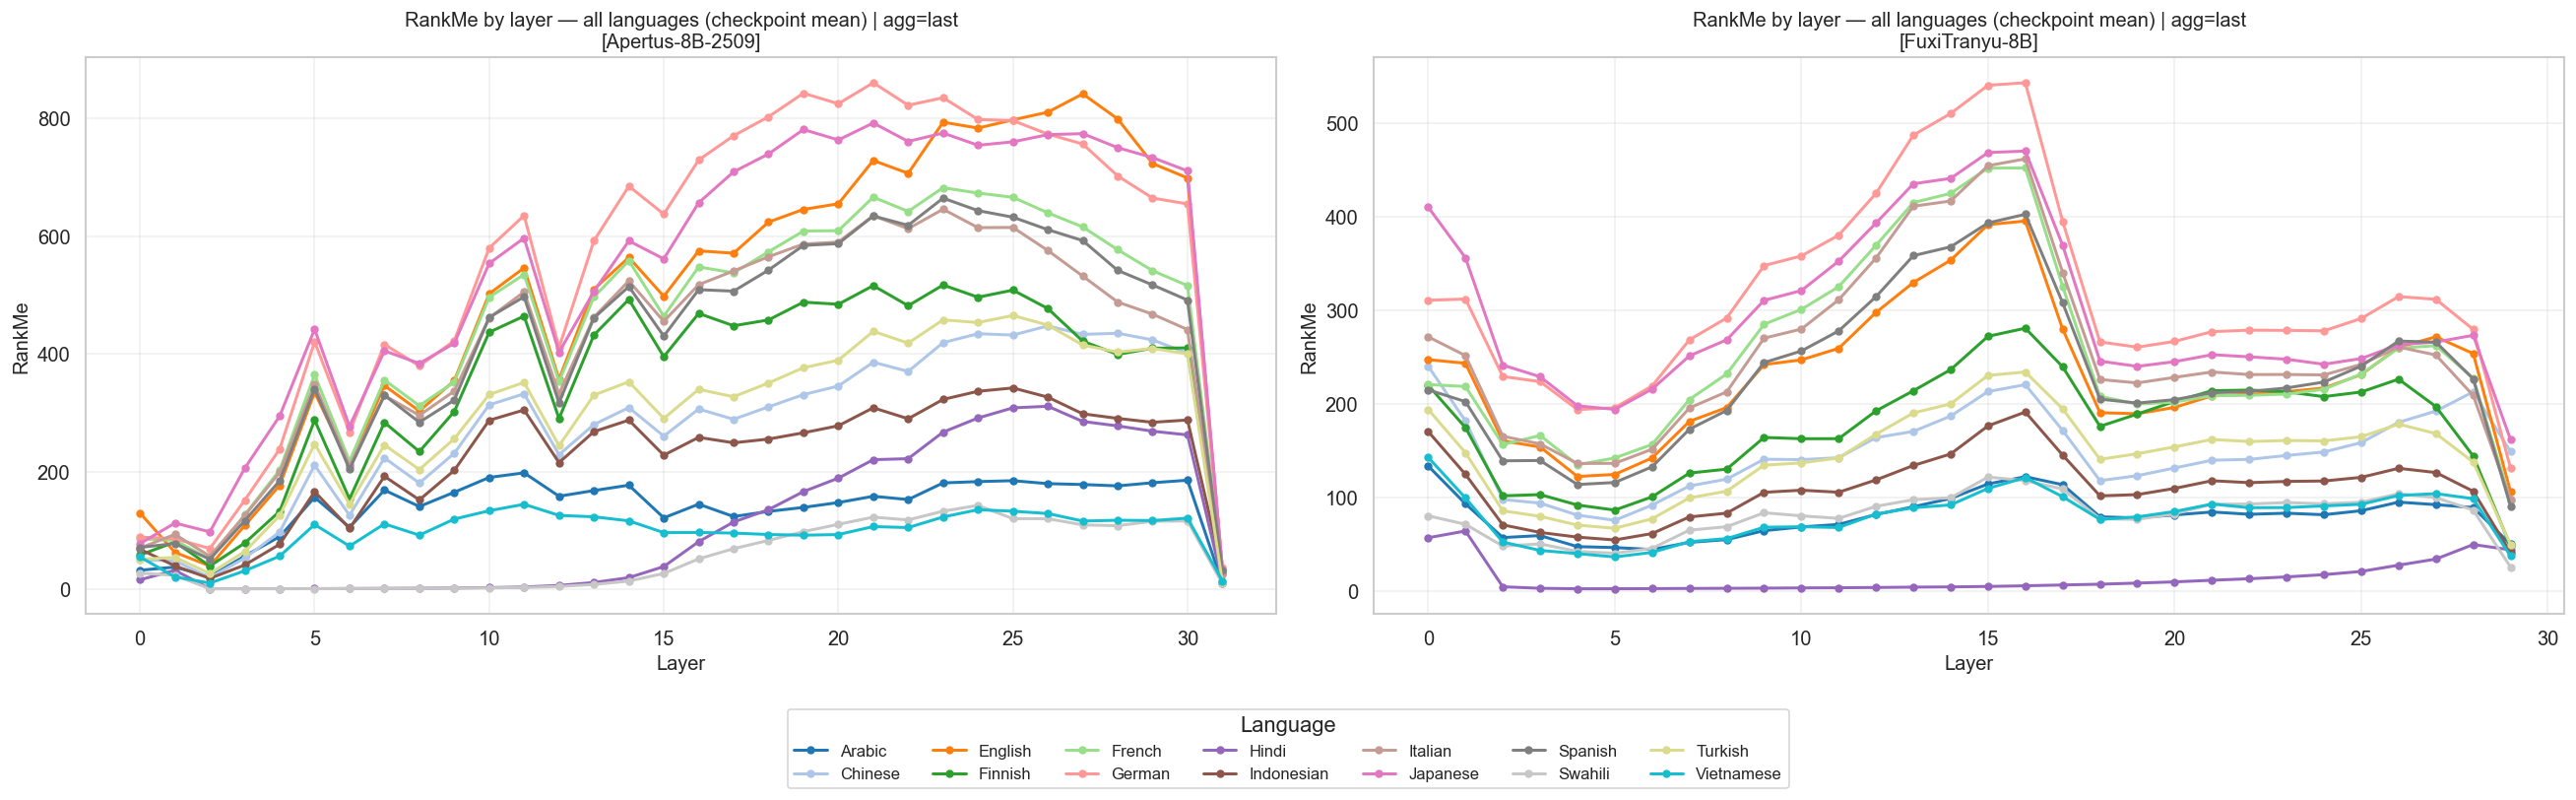

Saved to statics_pedro/rankme_by_layer_mean_both.png


In [21]:
LANG_COLORS = {
    lang: plt.cm.tab20(i / 14)
    for i, lang in enumerate(sorted(langs_f))
}

def plot_layer_mean(ax, df, layers, lnums, langs, label):
    mean_df = (
        df.groupby(["layer", "dataset"])[METRIC]
        .mean()
        .reset_index()
    )
    for lang in sorted(langs):
        sub = (
            mean_df[mean_df.dataset == lang]
            .set_index("layer")
            .reindex(layers)
            .reset_index()
        )
        ax.plot(
            lnums, sub[METRIC],
            marker="o", ms=4, lw=1.8,
            color=LANG_COLORS.get(lang, "gray"),
            label=lang,
        )
    ax.set_xlabel("Layer", fontsize=12)
    ax.set_ylabel("RankMe", fontsize=12)
    ax.set_title(
        f"RankMe by layer — all languages (checkpoint mean) | agg={AGG}\n[{label}]",
        fontsize=12,
    )
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
plot_layer_mean(axes[0], dfa, layers_a, lnums_a, langs_a, APERTUS_LABEL)
plot_layer_mean(axes[1], dff, layers_f, lnums_f, langs_f, FUXI_LABEL)

# Shared legend below both panels
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title="Language",
    loc="lower center",
    ncol=7,
    fontsize=10,
    bbox_to_anchor=(0.5, -0.14),
)
plt.tight_layout()
out = STATICS_DIR / "rankme_by_layer_mean_both.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out}")

### Observations

**Apertus-8B-2509** (left): RankMe grows monotonically from layer 0 to ~layer 25, then plateaus or slightly declines at the final layers. Languages **stratify strongly and consistently** from early layers: German, French, English and Japanese occupy the top band throughout, while Hindi and Swahili remain in the bottom band. The separation is already visible at layer 5 and is maintained until the final layer. This suggests Apertus builds language-specific representations early and preserves that stratification through training.

**FuxiTranyu-8B** (right): The profile is qualitatively different — RankMe rises to a clear **mid-layer peak at layers 14–16**, then drops sharply at layer 17 before partially recovering. This is consistent with a compression-seeking phase at mid-depth. Hindi is a strong outlier, remaining near zero across all layers (likely driven by very low training data proportion for Hindi in Fuxi's corpus). The sharp mid-layer collapse is not present in Apertus, pointing to a fundamental architectural or training-regime difference.

## 3. Checkpoint Stability of Layer Profiles (H1)

We plot individual per-checkpoint layer profiles with transparency to see whether
the shape is preserved across training (only the scale shifts) or if the shape
itself evolves.

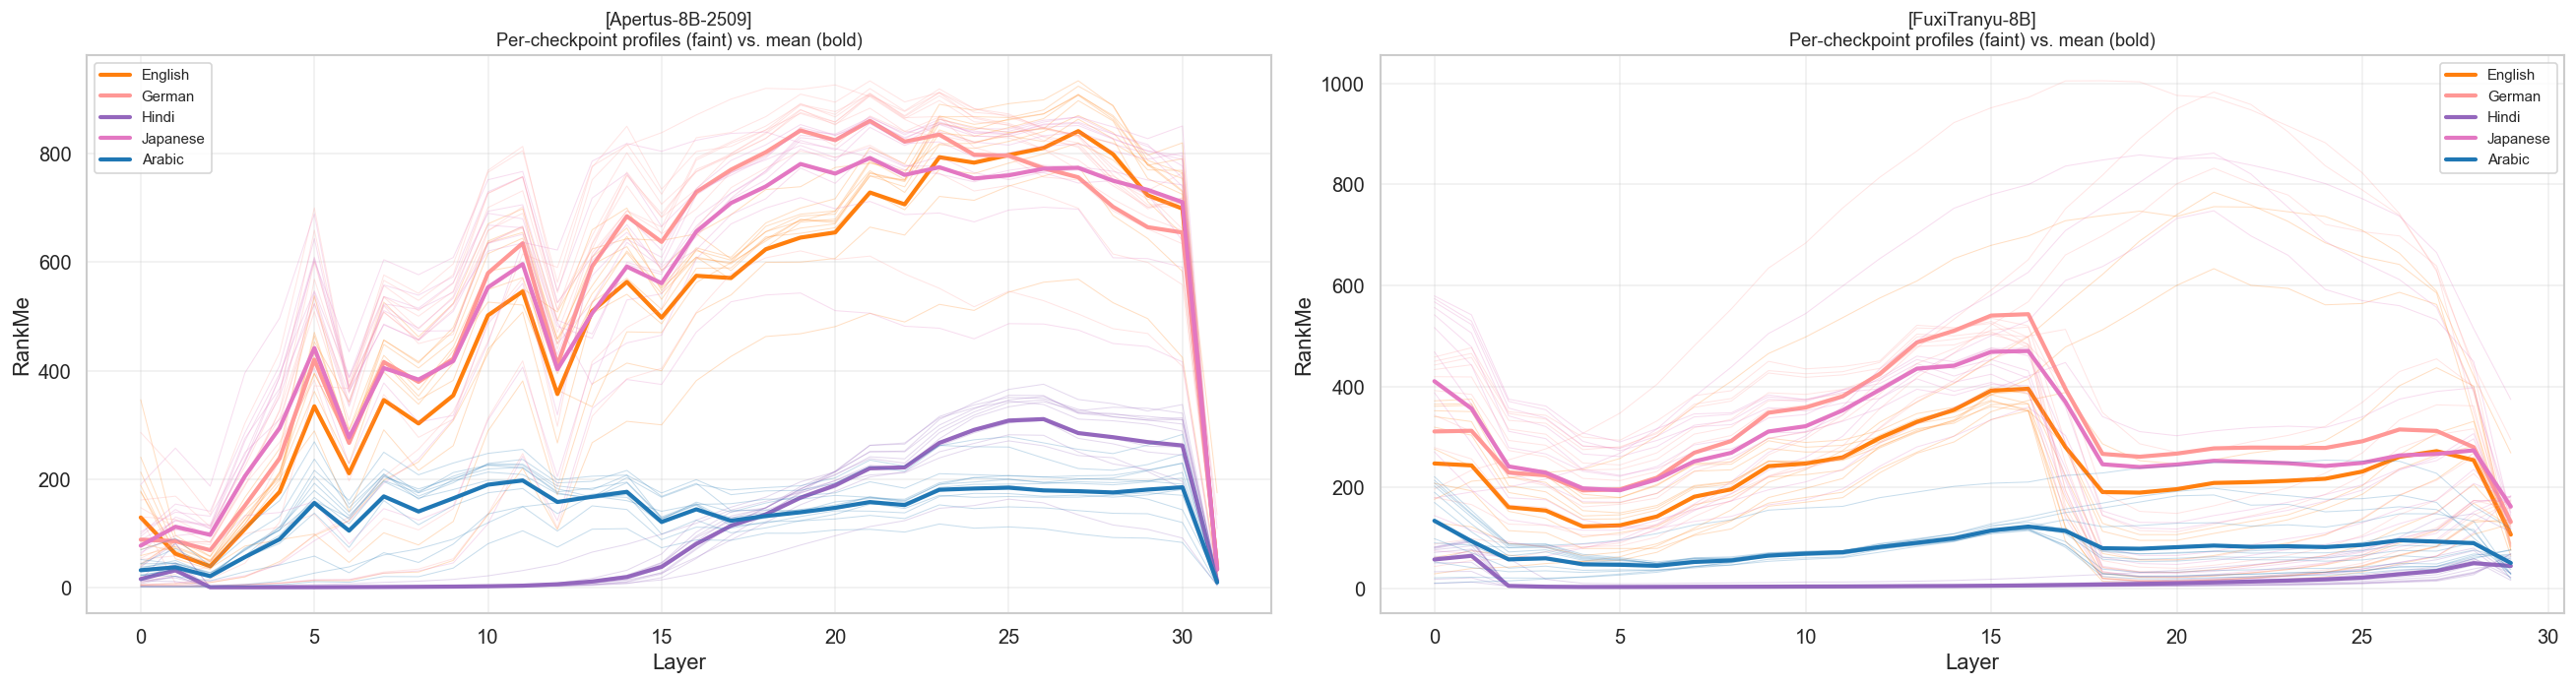

Saved to statics_pedro/stability_profiles.png


In [22]:
def plot_stability(ax, df, layers, lnums, ckpts, langs, label, n_ckpts_shown=10):
    """Overlay a subset of checkpoint profiles (light) + the checkpoint mean (bold)."""
    # Evenly sample checkpoints to avoid overplotting
    step = max(1, len(ckpts) // n_ckpts_shown)
    shown = ckpts[::step]

    # Pick a few representative languages for readability
    highlight = ["English", "German", "Hindi", "Japanese", "Arabic"]
    highlight = [l for l in highlight if l in langs]

    mean_df = df.groupby(["layer", "dataset"])[METRIC].mean().reset_index()

    for lang in highlight:
        color = LANG_COLORS.get(lang, "gray")
        for ckpt in shown:
            sub = (
                df[(df.checkpoint == ckpt) & (df.dataset == lang)]
                .set_index("layer").reindex(layers).reset_index()
            )
            ax.plot(lnums, sub[METRIC], lw=0.6, alpha=0.25, color=color)
        # Bold mean line
        m = (
            mean_df[mean_df.dataset == lang]
            .set_index("layer").reindex(layers).reset_index()
        )
        ax.plot(lnums, m[METRIC], lw=2.5, color=color, label=lang)

    ax.set_xlabel("Layer"); ax.set_ylabel("RankMe")
    ax.set_title(f"[{label}]\nPer-checkpoint profiles (faint) vs. mean (bold)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(22, 6))
plot_stability(axes[0], dfa, layers_a, lnums_a, ckpts_a, langs_a, APERTUS_LABEL)
plot_stability(axes[1], dff, layers_f, lnums_f, ckpts_f, langs_f, FUXI_LABEL)
plt.tight_layout()
out = STATICS_DIR / "stability_profiles.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out}")

### Observations

For both models the per-checkpoint profiles (faint lines) trace closely around the mean (bold), confirming **H1**: the depth profile shape is largely stable across training. The principal change over training is an upward shift in magnitude (the model increases effective rank as it trains), not a reshape of the depth curve. This means the checkpoint-mean plot in Section 2 is a faithful summary of the model's geometric behavior.

## 4. Language Stratification by Layer (H2)

We quantify cross-language spread at each layer by computing the **standard deviation
of RankMe across languages** (averaged over checkpoints). A high std at a given layer
means languages disagree strongly — the geometry there is language-specific.

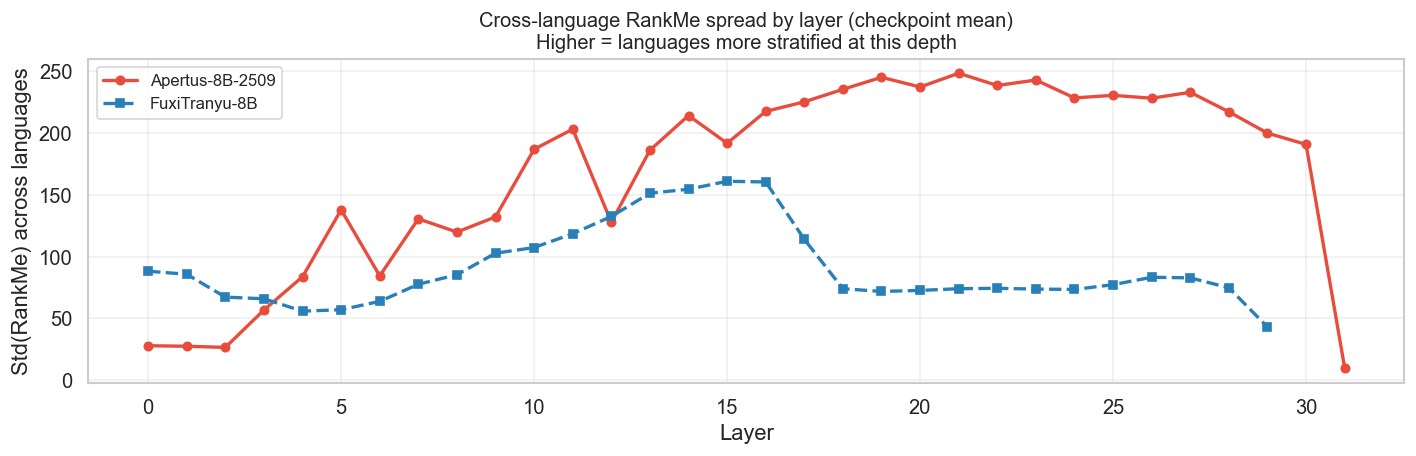

[FuxiTranyu-8B]    peak spread at layer 15
[Apertus-8B-2509] peak spread at layer 21


In [23]:
def layer_std(df, layers):
    mean_df = df.groupby(["layer", "dataset"])[METRIC].mean().reset_index()
    stds = []
    for layer in layers:
        vals = mean_df[mean_df.layer == layer][METRIC].values
        stds.append(vals.std() if len(vals) > 1 else 0.0)
    return np.array(stds)

std_f = layer_std(dff, layers_f)
std_a = layer_std(dfa, layers_a)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(lnums_a, std_a, "o-", lw=2, ms=5, color="#e74c3c", label=APERTUS_LABEL)
ax.plot(lnums_f, std_f, "s--", lw=2, ms=5, color="#2980b9", label=FUXI_LABEL)
ax.set_xlabel("Layer")
ax.set_ylabel("Std(RankMe) across languages")
ax.set_title("Cross-language RankMe spread by layer (checkpoint mean)\n"
             "Higher = languages more stratified at this depth", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out = STATICS_DIR / "stratification_by_layer.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()

print(f"[{FUXI_LABEL}]    peak spread at layer {lnums_f[std_f.argmax()]}")
print(f"[{APERTUS_LABEL}] peak spread at layer {lnums_a[std_a.argmax()]}")

### Observations

Both models show increasing cross-language spread with depth, supporting **H2**. However the pattern differs:

- **Fuxi**: spread rises through the early layers, peaks around the mid-layer region (consistent with the RankMe peak at layers 14–16), then drops sharply at the compression transition. Languages converge at the collapse point and partially re-stratify in final layers.
- **Apertus**: spread grows more continuously, peaking in the upper-middle layers (~layer 20–25) before a modest decline at the final layers. There is no sudden collapse.

The finding confirms that the strongest language-specific signal lives in the **middle-to-late layers** in both models, not the early or final layers.

## 5. Training Trajectory Heatmap

A heatmap of RankMe over `(checkpoint × layer)` for a single language shows how geometry
evolves jointly across time and depth. We show English (representative of the majority of
training data) and Hindi (the lowest-RankMe language) for both models.

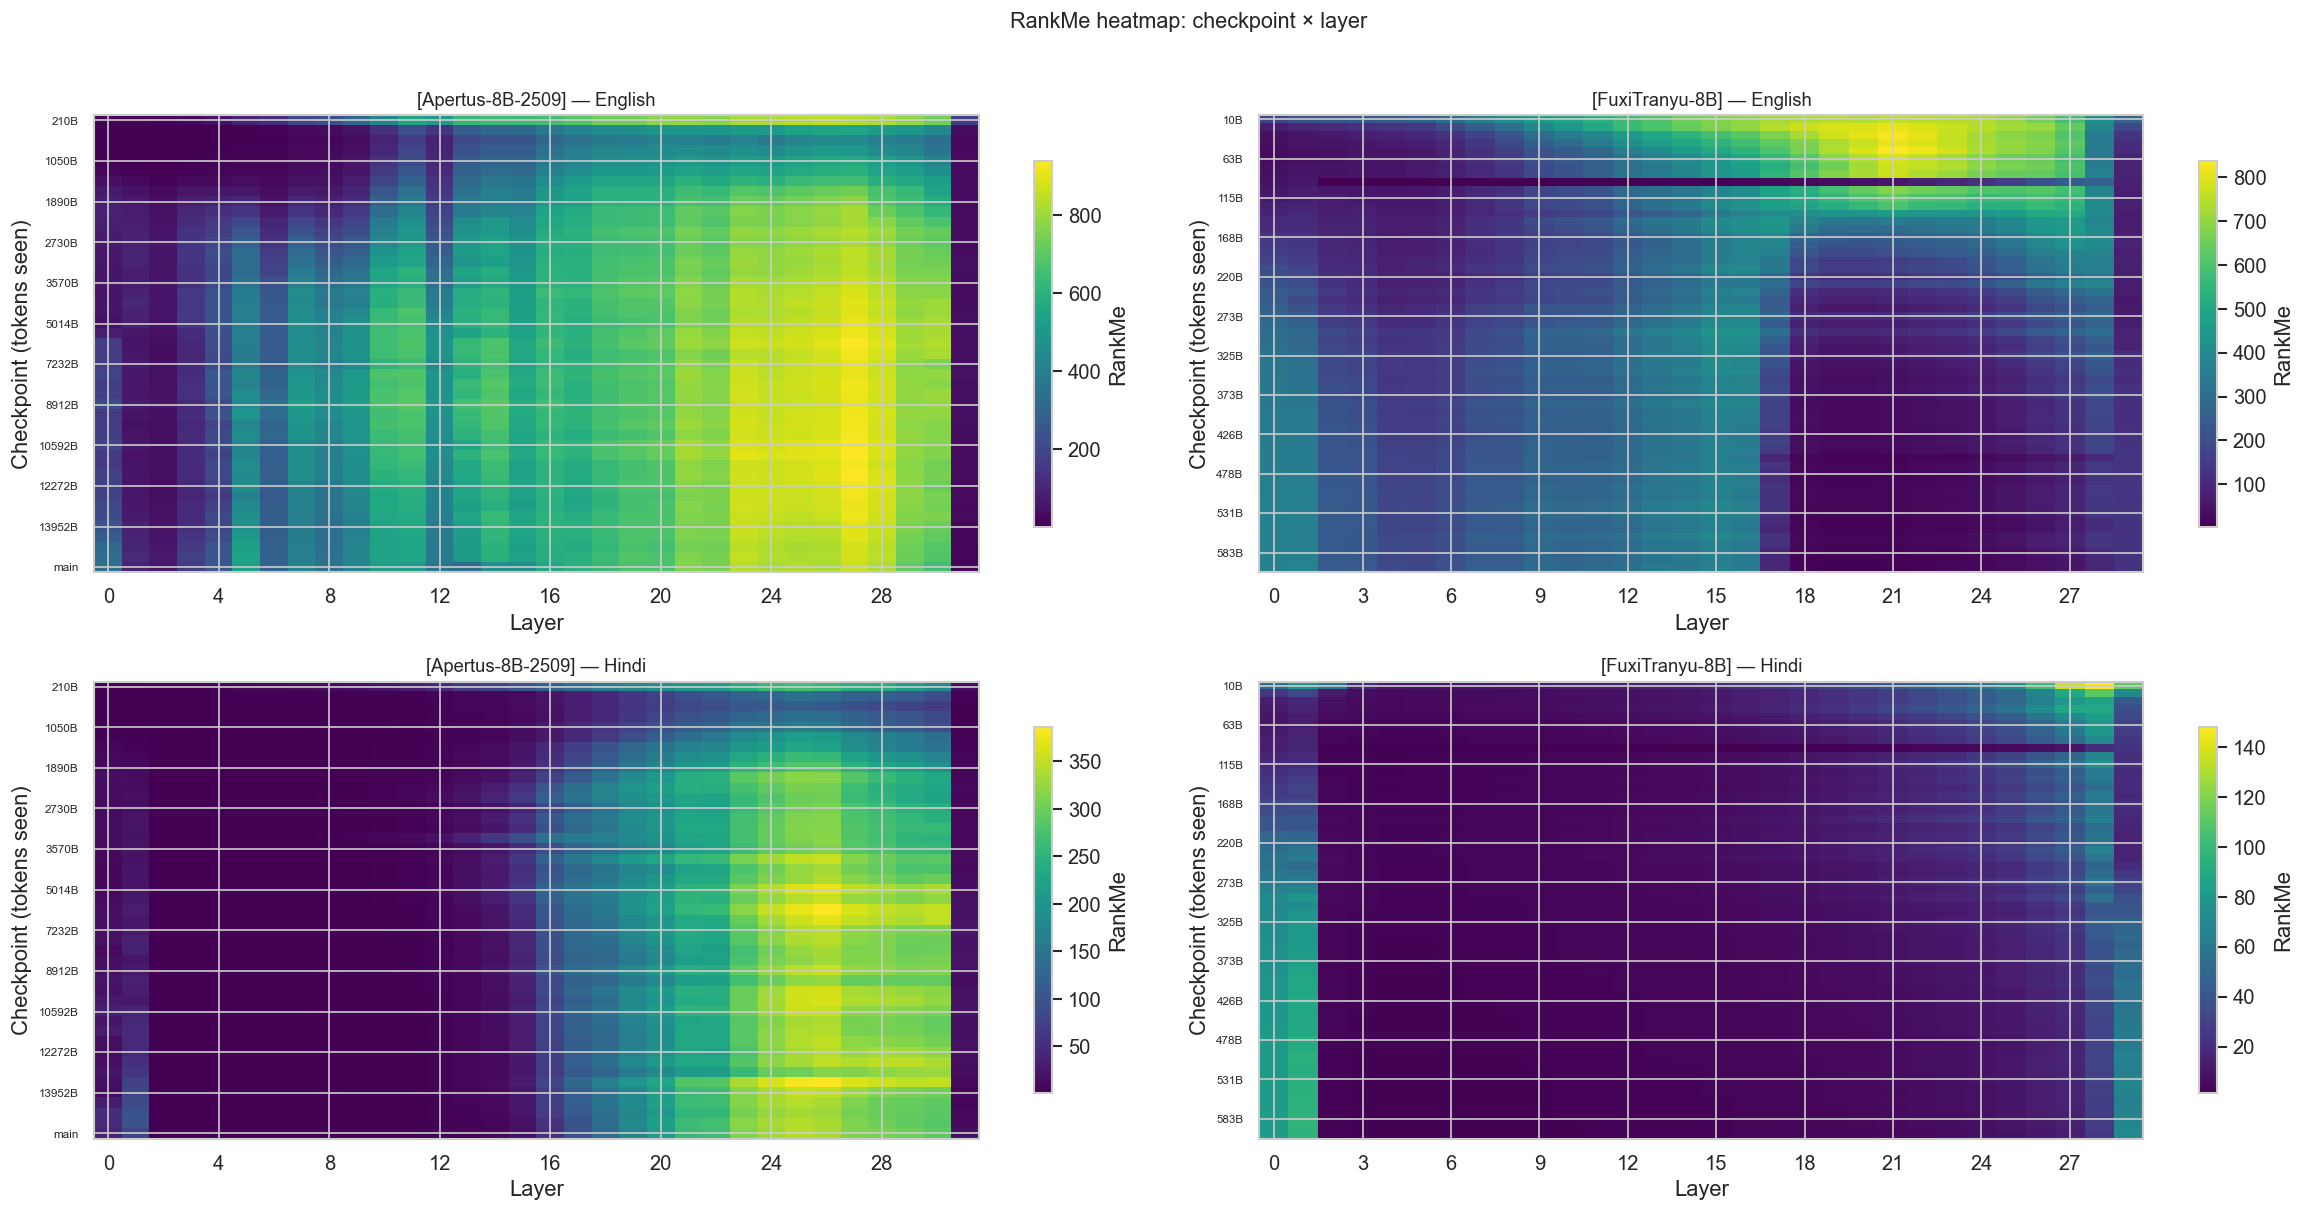

Saved to statics_pedro/heatmap_ckpt_x_layer.png


In [24]:
def build_heatmap(df, ckpts, layers):
    mat = np.full((len(ckpts), len(layers)), np.nan)
    for ci, ck in enumerate(ckpts):
        for li, ly in enumerate(layers):
            val = df[(df.checkpoint == ck) & (df.layer == ly)][METRIC].values
            if len(val):
                mat[ci, li] = val[0]
    return mat

highlight_langs = ["English", "Hindi"]

fig, axes = plt.subplots(2, 2, figsize=(20, 10))
for row, lang in enumerate(highlight_langs):
    for col, (df, ckpts, layers, lnums, label, clabs) in enumerate([
        (dfa, ckpts_a, layers_a, lnums_a, APERTUS_LABEL, [ckpt_label(c) for c in ckpts_a]),
        (dff, ckpts_f, layers_f, lnums_f, FUXI_LABEL,    [ckpt_label(c) for c in ckpts_f]),
    ]):
        sub = df[df.dataset == lang]
        mat = build_heatmap(sub, ckpts, layers)
        ax = axes[row, col]
        im = ax.imshow(mat, aspect="auto", cmap="viridis", interpolation="nearest")
        plt.colorbar(im, ax=ax, label="RankMe", shrink=0.8)
        # X: layers (subsample ticks)
        xtick_pos = list(range(0, len(lnums), max(1, len(lnums) // 8)))
        ax.set_xticks(xtick_pos)
        ax.set_xticklabels([lnums[i] for i in xtick_pos])
        # Y: checkpoints (subsample ticks)
        ytick_pos = list(range(0, len(clabs), max(1, len(clabs) // 10)))
        ax.set_yticks(ytick_pos)
        ax.set_yticklabels([clabs[i] for i in ytick_pos], fontsize=7)
        ax.set_xlabel("Layer")
        ax.set_ylabel("Checkpoint (tokens seen)")
        ax.set_title(f"[{label}] — {lang}", fontsize=11)

fig.suptitle("RankMe heatmap: checkpoint × layer", fontsize=13, y=1.01)
plt.tight_layout()
out = STATICS_DIR / "heatmap_ckpt_x_layer.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {out}")

### Observations

The heatmaps confirm the stability finding from Section 3: the bright/dark pattern along the layer axis is consistent across checkpoints (rows are similar), while the overall brightness increases from top to bottom as training progresses.

For **Hindi in Fuxi**, the near-zero RankMe across almost all layers and checkpoints stands out starkly — the model never develops rich Hindi representations, likely because Hindi is severely under-represented in Fuxi's training corpus.

## 6. Language Clustering by Layer Profile (H3)

We use agglomerative clustering on the mean layer-profile vectors to discover which
languages group together geometrically. Two languages are similar if their RankMe
evolves with similar shape and magnitude across layers.

The layer-profile JSON files are pre-bundled in `statics_pedro/plots/` and load automatically.

In [25]:
for experiment, label in [
    ("fuxi_fine_wiki",    FUXI_LABEL),
    ("apertus_fine_wiki", APERTUS_LABEL),
]:
    json_dir = PLOTS_DIR / experiment / f"layer_profiles/{METRIC}"
    if not json_dir.exists():
        print(f"No layer profile JSONs for {experiment} — run visualize.py first.")
        continue

    profiles = load_layer_profiles(PLOTS_DIR, experiment, METRIC, AGG)
    if not profiles:
        print(f"No profiles loaded for {experiment}.")
        continue

    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"{'='*60}")
    print(f"Loaded {len(profiles)} languages: {sorted(profiles.keys())}")

    lang_list, dist_mat = compute_distance_matrix(profiles)
    cluster_labels = cluster_languages(dist_mat, k=K_CLUSTERS)

    print(f"\nClusters (k={K_CLUSTERS}):")
    for c in range(K_CLUSTERS):
        members = [lang_list[i] for i, lbl in enumerate(cluster_labels) if lbl == c]
        if members:
            print(f"  Cluster {c}: {members}")


FuxiTranyu-8B
Loaded 14 languages: ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']

Clusters (k=5):
  Cluster 0: ['Arabic', 'Indonesian', 'Swahili', 'Vietnamese']
  Cluster 1: ['English', 'French', 'Italian', 'Spanish']
  Cluster 2: ['Chinese', 'Finnish', 'Turkish']
  Cluster 3: ['German', 'Japanese']
  Cluster 4: ['Hindi']

Apertus-8B-2509
Loaded 14 languages: ['Arabic', 'Chinese', 'English', 'Finnish', 'French', 'German', 'Hindi', 'Indonesian', 'Italian', 'Japanese', 'Spanish', 'Swahili', 'Turkish', 'Vietnamese']

Clusters (k=5):
  Cluster 0: ['Chinese', 'Indonesian', 'Turkish']
  Cluster 1: ['English', 'German', 'Japanese']
  Cluster 2: ['Arabic', 'Hindi', 'Swahili', 'Vietnamese']
  Cluster 3: ['French', 'Italian', 'Spanish']
  Cluster 4: ['Finnish']


### Observations

The clustering reveals that languages group by a combination of script family, morphological complexity, and training data proportion — not purely by linguistic family.

**FuxiTranyu-8B:**
- **Cluster: German, Japanese** — both show high early-layer RankMe due to morphological complexity (compound words / character mixtures), then collapse at deep layers.
- **Cluster: English, French, Italian, Spanish** — similar European-language profile: moderate, steadily rising RankMe.
- **Cluster: Arabic, Indonesian, Swahili, Vietnamese** — low-resource-like profiles, flatter across layers.
- **Outlier: Hindi** — uniquely near-zero across all layers, confirming that Hindi training data is minimal in Fuxi.

**Apertus-8B-2509:**
Clusters differ from Fuxi: German and Japanese no longer group as outliers, suggesting Apertus has more balanced multilingual exposure in its training data. The language groupings are more consistent with linguistic typology.

## 7. Conclusions

### H1 — Depth profile shape is stable across training ✓
Both models show that the per-checkpoint layer profiles closely track the checkpoint mean.
Training primarily scales the magnitude of RankMe upward; the characteristic shape at each
depth is established early and maintained. The checkpoint-mean layer profile is therefore
a compact and faithful summary of each model's geometric structure.

### H2 — Languages stratify with depth ✓
Cross-language standard deviation grows with layer in both models, confirming that
language-specific signals are concentrated in the **middle-to-late layers**. Early layers
are more uniform across languages, while deep layers carry the strongest language-specific
geometry.

### H3 — The two models have qualitatively different layer profiles ✓
| Aspect | FuxiTranyu-8B | Apertus-8B-2509 |
|--------|--------------|------------------|
| Overall shape | Rise → peak at layers 14–16 → sharp collapse | Monotone rise → plateau at ~layer 25 |
| Hindi | Near-zero throughout (severely under-resourced) | Low but non-zero |
| German/Japanese | Strong early outliers that converge later | Part of the majority cluster |
| Language clustering | Training-data-proportion dominates | More typology-consistent |

The **mid-layer collapse in Fuxi** is the most striking finding: it suggests a compression-seeking
phase concentrated at a specific network depth, which is absent in Apertus. Whether this is
driven by architecture (depth, head count, MLP ratio) or training data composition remains
an open question that cross-model ablation studies could resolve.